# LABORATORIO COMPLETO: Sistema Difuso para Evaluación de Prioridad de Beca
**Curso:** Sistemas Inteligentes  
**Institución:** Universidad César Vallejo  
**Escuela Profesional:** Ingeniería de Sistemas  
**Alumno:** Anderson Javier Musaja Lopez.

## 1. Preparación del entorno
Instalación de las librerías necesarias (`numpy`, `matplotlib`, `scikit-fuzzy` y `pandas`) para construir el modelo de lógica difusa y graficar sus conjuntos.

In [11]:
%pip install numpy matplotlib scikit-fuzzy pandas -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importar librerías
Carga de módulos para el manejo de vectores numéricos, análisis de datos con DataFrames, renderizado de gráficos y el framework de control difuso de `skfuzzy`.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 3. Definir universos de discurso
El universo de discurso define el rango físico y los límites numéricos permitidos para cada una de nuestras variables:
* **Promedio académico:** Escala de 0 a 20.
* **Asistencia:** Escala de 0 a 100%.
* **Participación:** Escala de 0 a 10.
* **Prioridad de beca (Salida):** Escala de 0 a 100.

In [13]:
promedio = ctrl.Antecedent(np.arange(0, 21, 1), "promedio")
asistencia = ctrl.Antecedent(np.arange(0, 101, 1), "asistencia")
participacion = ctrl.Antecedent(np.arange(0, 11, 1), "participacion")

prioridad_beca = ctrl.Consequent(np.arange(0, 101, 1), "prioridad_beca")

## 4. Definir conjuntos difusos (Funciones de Pertenencia)
Se configuran las etiquetas lingüísticas ("bajo", "medio", "alto") mapeándolas mediante funciones de membresía triangulares (`trimf`) y trapezoidales (`trapmf`) para suavizar las transiciones de pertenencia.

In [14]:
# Promedio académico
promedio["bajo"] = fuzz.trapmf(promedio.universe, [0, 0, 10, 13])
promedio["medio"] = fuzz.trimf(promedio.universe, [11, 14, 17])
promedio["alto"] = fuzz.trapmf(promedio.universe, [15, 18, 20, 20])

# Asistencia
asistencia["baja"] = fuzz.trapmf(asistencia.universe, [0, 0, 50, 65])
asistencia["media"] = fuzz.trimf(asistencia.universe, [55, 75, 90])
asistencia["alta"] = fuzz.trapmf(asistencia.universe, [80, 90, 100, 100])

# Participación
participacion["baja"] = fuzz.trapmf(participacion.universe, [0, 0, 3, 5])
participacion["media"] = fuzz.trimf(participacion.universe, [4, 6, 8])
participacion["alta"] = fuzz.trapmf(participacion.universe, [7, 9, 10, 10])

# Prioridad de beca
prioridad_beca["baja"] = fuzz.trapmf(prioridad_beca.universe, [0, 0, 30, 45])
prioridad_beca["media"] = fuzz.trimf(prioridad_beca.universe, [35, 55, 75])
prioridad_beca["alta"] = fuzz.trapmf(prioridad_beca.universe, [65, 80, 100, 100])

## 5. Graficar conjuntos difusos
A continuación, se define una función auxiliar para graficar las curvas y trapecios visualizando el solapamiento o traslape entre las diferentes clasificaciones de nuestras variables.

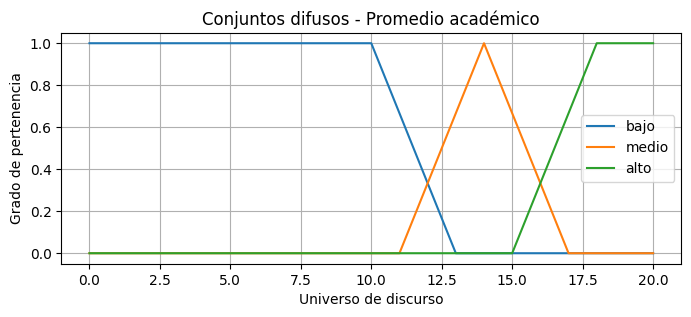

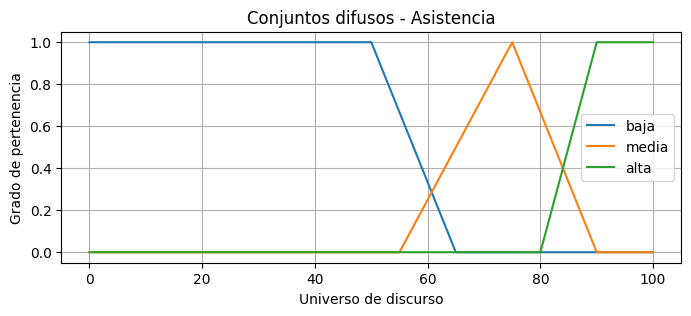

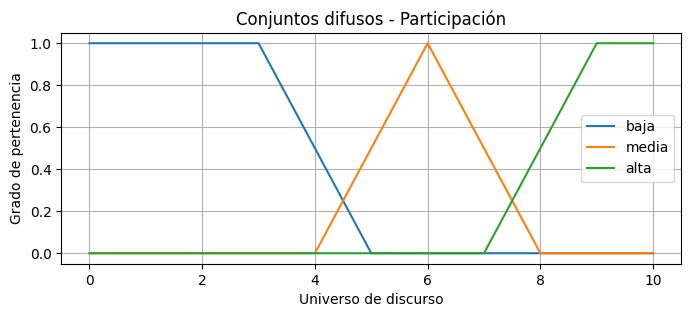

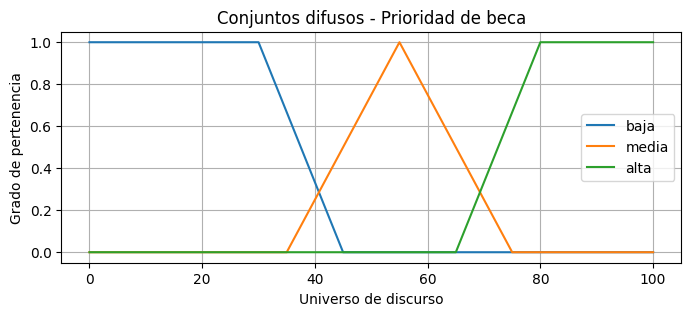

In [15]:
def plot_membership(variable, title):
    plt.figure(figsize=(8, 3))
    for term_name, term in variable.terms.items():
        plt.plot(variable.universe, term.mf, label=term_name)
    plt.title(title)
    plt.xlabel("Universo de discurso")
    plt.ylabel("Grado de pertenencia")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_membership(promedio, "Conjuntos difusos - Promedio académico")
plot_membership(asistencia, "Conjuntos difusos - Asistencia")
plot_membership(participacion, "Conjuntos difusos - Participación")
plot_membership(prioridad_beca, "Conjuntos difusos - Prioridad de beca")

## 6. Base de Reglas Difusas y Control del Sistema
Modelamos el criterio y conocimiento experto a través de 10 reglas condicionales utilizando conectores lógicos para vincular los antecedentes con el consecuente de asignación de prioridad.

In [16]:
rule_1 = ctrl.Rule(promedio["alto"] & asistencia["alta"], prioridad_beca["alta"])
rule_2 = ctrl.Rule(promedio["alto"] & participacion["alta"], prioridad_beca["alta"])
rule_3 = ctrl.Rule(promedio["medio"] & asistencia["alta"], prioridad_beca["media"])
rule_4 = ctrl.Rule(promedio["medio"] & participacion["media"], prioridad_beca["media"])
rule_5 = ctrl.Rule(promedio["bajo"] & asistencia["baja"], prioridad_beca["baja"])
rule_6 = ctrl.Rule(promedio["bajo"] & participacion["baja"], prioridad_beca["baja"])
rule_7 = ctrl.Rule(asistencia["media"] & participacion["alta"], prioridad_beca["media"])
rule_8 = ctrl.Rule(promedio["alto"] & asistencia["media"] & participacion["media"], prioridad_beca["alta"])
rule_9 = ctrl.Rule(promedio["medio"] & asistencia["media"] & participacion["baja"], prioridad_beca["media"])
rule_10 = ctrl.Rule(promedio["bajo"] & asistencia["alta"] & participacion["alta"], prioridad_beca["media"])

rules = [rule_1, rule_2, rule_3, rule_4, rule_5, rule_6, rule_7, rule_8, rule_9, rule_10]
scholarship_control = ctrl.ControlSystem(rules)

## 7. Evaluación de Estudiantes y Comparación con Lógica Rígida
Se encapsula el proceso de inferencia en la función `evaluate_student` para procesar múltiples registros académicos simultáneamente y comparamos el comportamiento difuso flexible contra un condicional rígido convencional (`IF-ELSE`).

In [17]:
def evaluate_student(promedio_value, asistencia_value, participacion_value):
    simulator = ctrl.ControlSystemSimulation(scholarship_control)
    simulator.input["promedio"] = promedio_value
    simulator.input["asistencia"] = asistencia_value
    simulator.input["participacion"] = participacion_value
    simulator.compute()
    score = simulator.output["prioridad_beca"]
    
    if score < 40: category = "Baja prioridad"
    elif score < 70: category = "Prioridad media"
    else: category = "Alta prioridad"
    
    return {
        "promedio": promedio_value, 
        "asistencia": asistencia_value, 
        "participacion": participacion_value, 
        "prioridad_score": round(score, 2), 
        "categoria": category
    }

def rigid_rule(promedio_value, asistencia_value, participacion_value):
    if promedio_value >= 16 and asistencia_value >= 80 and participacion_value >= 7:
        return "Alta prioridad"
    return "No alta prioridad"

# Lote de estudiantes de prueba según la guía
students = [(19, 95, 9), (16, 85, 7), (13, 78, 6), (11, 60, 4), (9, 45, 2), (12, 95, 9), (18, 70, 5)]
results = [evaluate_student(*student) for student in students]
results_df = pd.DataFrame(results)
results_df["regla_rigida"] = results_df.apply(lambda row: rigid_rule(row["promedio"], row["asistencia"], row["participacion"]), axis=1)

results_df

,promedio,asistencia,participacion,prioridad_score,categoria,regla_rigida
0,19,95,9,85.91,Alta prioridad,Alta prioridad
1,16,85,7,69.14,Prioridad media,Alta prioridad
2,13,78,6,55.00,Prioridad media,No alta prioridad
3,11,60,4,20.68,Baja prioridad,No alta prioridad
4,9,45,2,19.00,Baja prioridad,No alta prioridad
5,12,95,9,55.00,Prioridad media,No alta prioridad
6,18,70,5,84.30,Alta prioridad,No alta prioridad


##  Desarrollo del Reto MIT (Incorporación de Variable Socioeconómica)
Ampliamos el modelo agregando la variable `situacion_economica` (escala 0 a 10, donde 10 representa mayor vulnerabilidad) y creamos 4 reglas adicionales para equilibrar la equidad del sistema. Comparamos el impacto resultante en un perfil regular.

In [18]:
# Nueva entrada difusa para el Reto MIT
situacion_economica = ctrl.Antecedent(np.arange(0, 11, 1), "situacion_economica")
situacion_economica["baja"] = fuzz.trapmf(situacion_economica.universe, [0, 0, 3, 5])
situacion_economica["media"] = fuzz.trimf(situacion_economica.universe, [4, 6, 8])
situacion_economica["alta"] = fuzz.trapmf(situacion_economica.universe, [7, 9, 10, 10])

# Duplicamos y expandimos la base de conocimiento
extended_rules = rules.copy()
extended_rules.append(ctrl.Rule(situacion_economica["alta"] & promedio["medio"], prioridad_beca["alta"]))
extended_rules.append(ctrl.Rule(situacion_economica["alta"] & asistencia["alta"], prioridad_beca["alta"]))
extended_rules.append(ctrl.Rule(situacion_economica["baja"] & promedio["medio"], prioridad_beca["baja"]))
extended_rules.append(ctrl.Rule(situacion_economica["media"] & promedio["bajo"], prioridad_beca["baja"]))

new_control_system = ctrl.ControlSystem(extended_rules)

def evaluate_student_mit(promedio_val, asistencia_val, participacion_val, socio_val):
    sim = ctrl.ControlSystemSimulation(new_control_system)
    sim.input["promedio"] = promedio_val
    sim.input["asistencia"] = asistencia_val
    sim.input["participacion"] = participacion_val
    sim.input["situacion_economica"] = socio_val
    sim.compute()
    return round(sim.output["prioridad_beca"], 2)

# Demostración del impacto comparativo
score_previo = results_df.loc[2, "prioridad_score"] # Estudiante con Promedio=13, Asistencia=78, Participación=6
score_nuevo = evaluate_student_mit(13, 78, 6, 9)   # Mismo estudiante, pero con alta necesidad económica (9)

print(f"Comparativa Reto MIT:\n -> Prioridad Original (Sin Variable Económica): {score_previo}\n -> Nueva Prioridad (Con Alta Necesidad Económica [9]): {score_nuevo}")

Comparativa Reto MIT:
 -> Prioridad Original (Sin Variable Económica): 55.0
 -> Nueva Prioridad (Con Alta Necesidad Económica [9]): 70.85
